

This workflow requires the **scKTLD** package for single-cell TAD detection.

Before running the analysis:

1. Create a new Python environment.
2. Install the [scKTLD package](https://github.com/lhqxinghun/scKTLD) following the instructions provided on the project's GitHub page.
3. Generate band-normalized contact matrices using the BandNorm normalization workflow provided in the BandNorm repository. These normalized contact matrices are used as input for the downstream TAD detection analysis.



After generating normalized text files, run the script `2.1_scKTLD_TADs_detection.py` provided in the `tad_detection/` directory.

The output directory will contain one TAD file per cell with the following structure:

```text
start_bin    end_bin
0            41
41           48
48           107
107          114
114          139
```

Each row represents a detected TAD boundary interval.

**Notes**

**The original scKTLD package generates additional outputs and visualization plots. These files are retained in the workflow but are not used in the analyses reported in this study.**


Current working directory: /Users/mozhganoroujlu
Number of bins: 391, Number of cells: 66
(391, 391)
neg 0.0005016326904296875
sparsesvd time 0.002191781997680664
Chebyshev expansion
Node embedding done!
Starting TAD boundary detection
TAD boundary detection Done!
Saved TAD boundaries: /Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/codes_figures/folders/normalized_contacts/bandnorm/temp_tads/AAACTCGCACTTTGGA_tads.txt
(391, 391)
neg 0.0003409385681152344
sparsesvd time 0.002846956253051758
Chebyshev expansion
Node embedding done!
Starting TAD boundary detection
TAD boundary detection Done!
Saved TAD boundaries: /Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/codes_figures/folders/normalized_contacts/bandnorm/temp_tads/AACCGATCAAGACTTC_tads.txt
(391, 391)
neg 0.0003838539123535156
sparsesvd time 0.0028281211853027344
Chebyshev expansion
Node embedding done!
Starting TAD boundary detection
TAD boundary detection Done!
Saved TAD boundaries: /Users/mozhganoroujlu/Desktop/MOZHGUN/

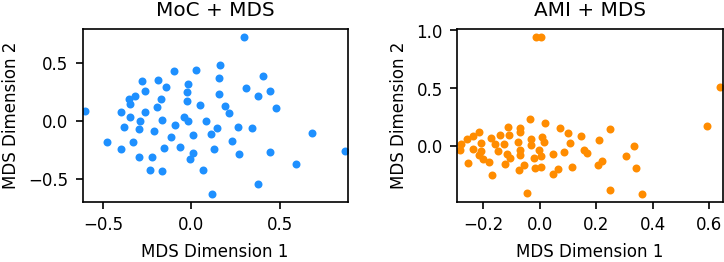

In [3]:

"""
Created on Tue Oct  7 16:00:17 2025

@author: mozhganoroujlu
"""


import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import os
import pandas as pd
from scKTLD import callTLD, metrics_similarity

# Specify your input and output directories
dir_input = "/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/codes_figures/folders/normalized_contacts/bandnorm/temp_files/"
output_tads_dir = "/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/codes_figures/folders/normalized_contacts/bandnorm/temp_tads/"

# Create output_tads directory if it doesn't exist
os.makedirs(output_tads_dir, exist_ok=True)

# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# Determine the number of bins (maximum bin ID + 1, assuming 0-based or 1-based IDs)
def get_max_bin_id(directory):
    max_bin_id = 0
    for cell in os.listdir(directory):
        path = os.path.join(directory, cell)
        if path.endswith(".txt"):  # Ensure only .txt files are processed
            data = np.loadtxt(path, dtype=float)  # Read edge-list data
            max_bin_id = max(max_bin_id, int(np.max(data[:, 0])), int(np.max(data[:, 1])))
    return max_bin_id + 1  # Add 1 to account for 0-based or 1-based indexing

num_bins = get_max_bin_id(dir_input)
num_cells = len([f for f in os.listdir(dir_input) if f.endswith(".txt")])  # Count .txt files
print(f"Number of bins: {num_bins}, Number of cells: {num_cells}")

# Initialize arrays for clustering and domain lists
arr_cluster = np.zeros((num_cells, num_bins))  # Cluster assignments for each cell
list_domain = []  # List of domain boundaries

# Process each cell's data and save TAD boundaries
m = 0
for cell in os.listdir(dir_input):
    if cell.endswith(".txt"):  # Process only .txt files
        path_input = os.path.join(dir_input, cell)
        # Read edge-list data
        edge_data = np.loadtxt(path_input, dtype=float)
        
        # Convert edge-list to adjacency matrix
        graph_adj = np.zeros((num_bins, num_bins))
        for row in edge_data:
            i, j, contact = int(row[0]), int(row[1]), row[2]
            graph_adj[i, j] = contact
            graph_adj[j, i] = contact  # Ensure symmetry (Hi-C matrices are typically symmetric)
        
        # Call TAD-like domains
        boundary_spec = callTLD(graph_adj, dimension=16)
        cluster_temp = np.repeat(np.arange(0, len(boundary_spec)-1), np.diff(boundary_spec))
        cluster_temp = np.append(cluster_temp, cluster_temp[-1])  # Pad to match num_bins
        if len(cluster_temp) < num_bins:
            cluster_temp = np.pad(cluster_temp, (0, num_bins - len(cluster_temp)), mode='edge')
        arr_cluster[m, :] = cluster_temp[:num_bins]  # Truncate if too long
        list_domain.append(np.vstack((boundary_spec[:-1], boundary_spec[1:])).transpose())
        
        # Save TAD boundaries to a .txt file
        output_file = os.path.join(output_tads_dir, f"{os.path.splitext(cell)[0]}_tads.txt")
        np.savetxt(output_file, list_domain[-1], fmt='%d', header='start_bin\tend_bin', comments='')
        print(f"Saved TAD boundaries: {output_file}")
        m += 1

# Calculate similarity matrices
simi_moc = np.zeros((num_cells, num_cells))
for i in range(num_cells):
    for j in range(i + 1):
        simi_moc[i, j] = metrics_similarity.moc(list_domain[i], list_domain[j])
simi_moc = simi_moc + simi_moc.T - np.diag(np.diag(simi_moc))  # Make symmetric

simi_ami = np.zeros((num_cells, num_cells))
for i in range(num_cells):
    for j in range(i + 1):
        simi_ami[i, j] = metrics_similarity.ami(arr_cluster[i], arr_cluster[j])
simi_ami = simi_ami + simi_ami.T - np.diag(np.diag(simi_ami))  # Make symmetric

# Save similarity matrices to Excel files in output_tads_dir
try:
    simi_moc_file = os.path.join(output_tads_dir, "simi_moc.xlsx")
    pd.DataFrame(simi_moc).to_excel(simi_moc_file, index=False, header=False)
    print(f"Saved similarity matrix: {simi_moc_file}")
except Exception as e:
    print(f"Error saving simi_moc.xlsx: {e}")

try:
    simi_ami_file = os.path.join(output_tads_dir, "simi_ami.xlsx")
    pd.DataFrame(simi_ami).to_excel(simi_ami_file, index=False, header=False)
    print(f"Saved similarity matrix: {simi_ami_file}")
except Exception as e:
    print(f"Error saving simi_ami.xlsx: {e}")

# MDS embedding and visualization
fig = plt.figure(figsize=(13.0/2.54, 5.0/2.54), constrained_layout=False, dpi=150)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'  # Changed to avoid font warnings
plt.rcParams['font.size'] = 8
plt.rcParams['axes.xmargin'] = 0.01
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['savefig.bbox'] = 'tight'

# MoC + MDS
mds = sklearn.manifold.MDS(n_components=2, dissimilarity='precomputed')
embedding = mds.fit_transform(1 - simi_moc)
plt.subplot2grid((1, 2), (0, 0), rowspan=1, colspan=1)
plt.title("MoC + MDS")
plt.scatter(embedding[:, 0], embedding[:, 1], c='dodgerblue', s=8)
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")

# AMI + MDS
mds = sklearn.manifold.MDS(n_components=2, dissimilarity='precomputed')
embedding = mds.fit_transform(1 - simi_ami)
plt.subplot2grid((1, 2), (0, 1), rowspan=1, colspan=1)
plt.title("AMI + MDS")
plt.scatter(embedding[:, 0], embedding[:, 1], c='darkorange', s=8)
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")

plt.tight_layout()
plt.show()


#### Similarity Matrix Calculation

In addition to TAD detection, the workflow computes pairwise similarity matrices between cells using:

* MOC (Measure of Concordance)
* AMI (Adjusted Mutual Information)

The similarity matrices are calculated as:



In [5]:

simi_moc = np.zeros((num_cells, num_cells))
for i in range(num_cells):
    for j in range(i + 1):
        simi_moc[i, j] = metrics_similarity.moc(
            list_domain[i], list_domain[j]
        )
simi_moc = simi_moc + simi_moc.T - np.diag(np.diag(simi_moc))

simi_ami = np.zeros((num_cells, num_cells))
for i in range(num_cells):
    for j in range(i + 1):
        simi_ami[i, j] = metrics_similarity.ami(
            arr_cluster[i], arr_cluster[j]
        )
simi_ami = simi_ami + simi_ami.T - np.diag(np.diag(simi_ami))


The AMI similarity matrix is then saved as:

`simi_ami.xlsx`

and is used in all downstream analyses presented in this study.

